### Caricamento librerie necessarie e del dataset

In [1]:
# Librerie di base
import pandas as pd
import numpy as np
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
from scipy import stats

# Modelli
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from keras.layers import Dense, Input, BatchNormalization, Dropout
from sklearn.base import BaseEstimator, ClassifierMixin
from keras.models import Sequential
from keras.callbacks import EarlyStopping

# Per scaricare il dataset
from google.colab import drive
import gdown

In [2]:
drive.mount('/content/drive/')
file_path = '/content/drive/MyDrive/MachineLearning/StudentPerformance/dataset.csv'


# ID necessario ad identificare univocamente il file da caricare
file_id = "1CBhnOMYHd7Io106paEneJCrNu2RRjX7m"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "dataset.csv", quiet=False)

Mounted at /content/drive/


Downloading...
From: https://drive.google.com/uc?id=1CBhnOMYHd7Io106paEneJCrNu2RRjX7m
To: /content/dataset.csv
100%|██████████| 167k/167k [00:00<00:00, 4.50MB/s]


'dataset.csv'

In [3]:
dataset = pd.read_csv("dataset.csv")

### Analisi preliminari del dataset
Diamo uno sguardo al dataset per capire come è strutturato e quali informazioni contiene.
- Il dataset è composto 2392 istanze.
- Il dataset è composto da sole features numeriche
- Non ci sono valori mancanti.
- Non ci sono righe duplicate.

In [4]:
dataset.info()
print(f"\nNumero di righe duplicate: {sum(dataset.duplicated())}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB

Numero di righe duplica

### Generazione del taget
A partire dal GPA, costruiamo il target diviso in classi come segue:
- Se il GPA è compreso tra 0 e 1, il target è 0
- Se il GPA è compreso tra 1 e 2, il target è 1
- Se il GPA è compreso tra 2 e 3, il target è 2
- Se il GPA è compreso tra 3 e 4, il target è 3


In [5]:
# Intervalli per il GPA, che usiamo come target
bins = [0, 1, 2, 3, 4]
labels = ['0-1', '1-2', '2-3', '3-4']

# Nuova colonna con gli intervalli del GPA
dataset['GPA_interval'] = pd.cut(dataset['GPA'], bins=bins, labels=False, include_lowest=True).astype(int)
dataset[['GPA_interval', 'GPA']].head(10)

,GPA_interval,GPA
0,2,2.929196
1,3,3.042915
2,0,0.112602
3,2,2.054218
4,1,1.288061
5,3,3.084184
6,2,2.748237
7,1,1.360143
8,2,2.896819
9,3,3.573474


### Grafico di distribuzione del target
Mostriamo la distribuzione del target.
Vediamo che le classi sono sbilanciate, seguono una distribuzione simile a quella di una distribuzione normale. \
Dato che le classi sono sbilanciate, utilizzeremo la metrica F1 per valutare i modelli.

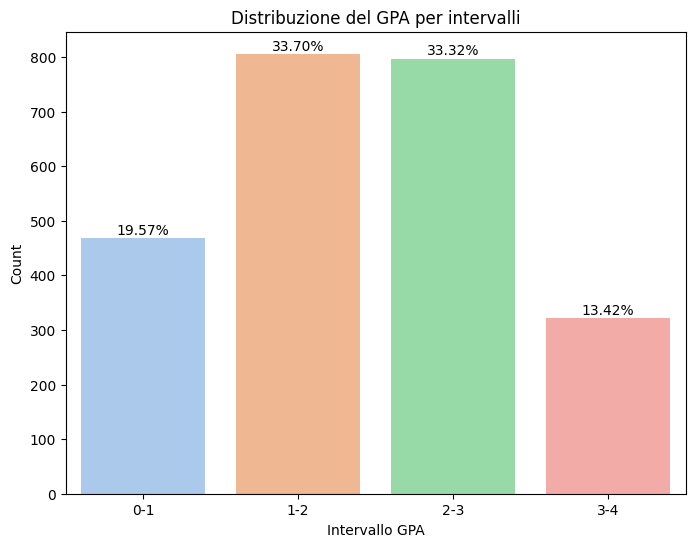

In [6]:
# Grafico a barre raggruppato con le percentuali di studenti per ogni intervallo di GPA

plt.figure(figsize=(8, 6))
sns.countplot(x='GPA_interval', data=dataset, palette="pastel", hue='GPA_interval', legend=False)
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(p.get_x() + p.get_width() / 2, height + 7, f'{height / len(dataset) * 100:.2f}%', ha='center')
plt.xlabel('Intervallo GPA')
plt.ylabel('Count')
plt.title('Distribuzione del GPA per intervalli')
plt.xticks(ticks=range(len(labels)), labels=labels, ha='center')
plt.show()

### Separazione di features e target
Separiamo le features dal target, e droppiamo alcune colonne:
- StudentID non è una caratteristica utile per la predizione
- GPA e GradeClass sono direttamente correlati al target, quindi non vanno usati come features
- GPA_interval è il target

In [7]:
# Separazione delle caratteristiche (features) e del target
dataset = dataset.drop(columns=['StudentID', 'GradeClass', 'GPA'])
featuresDataFrame = dataset.drop(columns=['GPA_interval'])
targetsDataFrame = dataset['GPA_interval']

In [8]:
featuresDataFrame.describe()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191
std,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057
min,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
75%,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000
max,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000


## Analisi delle features
Diamo uno sguardo alle features per capire come sono distribuite:
- Vediamo che la distribuzione dell'età e del sesso è bilanciata.
- L'etnia caucasica è la più presente, molto più rappresentata rispetto alle altre etnie.
- Il supporto parentale e l'istruzione parentale sono distribuiti in modo simile a una distribuzione normale.
- Gli studenti che svolgono attività extracurricolari sono di meno rispetto a quelli che non le svolgono.
- Notiamo inoltre che il tempo di studio e il numero di assenze, che a priori potrebbero essere le feature più significative per la predizione, sono distribuiti in modo abbastanza bilanciato.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Ethnicity'}>],
       [<Axes: title={'center': 'ParentalEducation'}>,
        <Axes: title={'center': 'StudyTimeWeekly'}>,
        <Axes: title={'center': 'Absences'}>],
       [<Axes: title={'center': 'Tutoring'}>,
        <Axes: title={'center': 'ParentalSupport'}>,
        <Axes: title={'center': 'Extracurricular'}>],
       [<Axes: title={'center': 'Sports'}>,
        <Axes: title={'center': 'Music'}>,
        <Axes: title={'center': 'Volunteering'}>]], dtype=object)

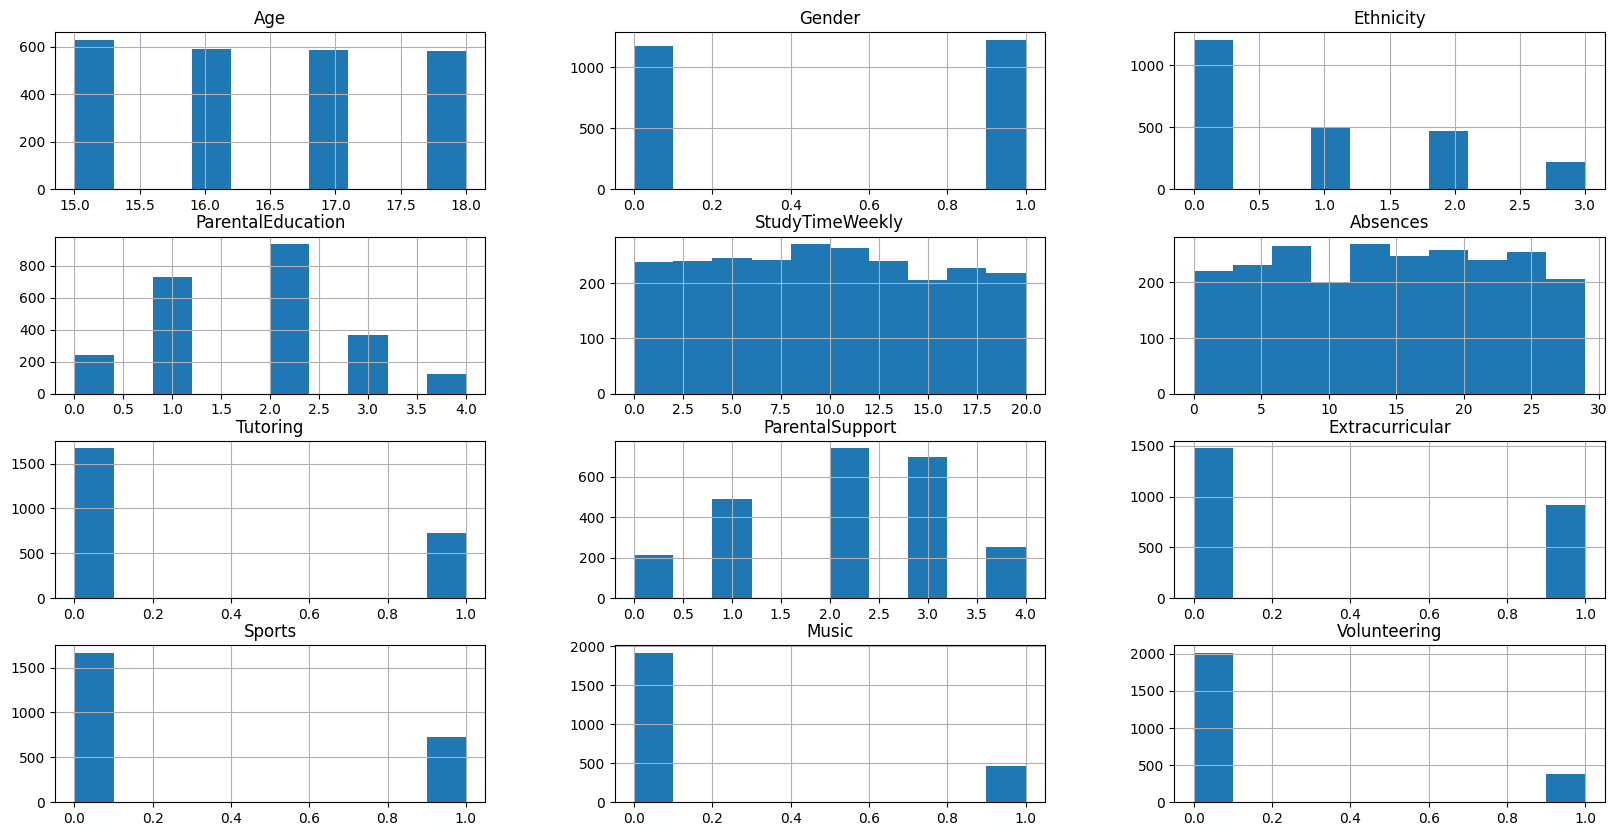

In [9]:
featuresDataFrame.hist(figsize=(20,10), bins=10)

### Correlazione tra le features
Calcoliamo la correlazione tra le features per capire se ci sono feature che sono correlate tra loro. \
Vediamo che l'unica correlazione significativa con il target è quella con il numero di assenze. La correlazione è negativa, questo perchè il target più alto corrisponde al voto maggiore. \
Notiamo inoltre che non ci sono correlazioni significative tra le features, questo indica che non c'è multicollinearità tra le features, quindi ogni feature porta informazioni uniche.

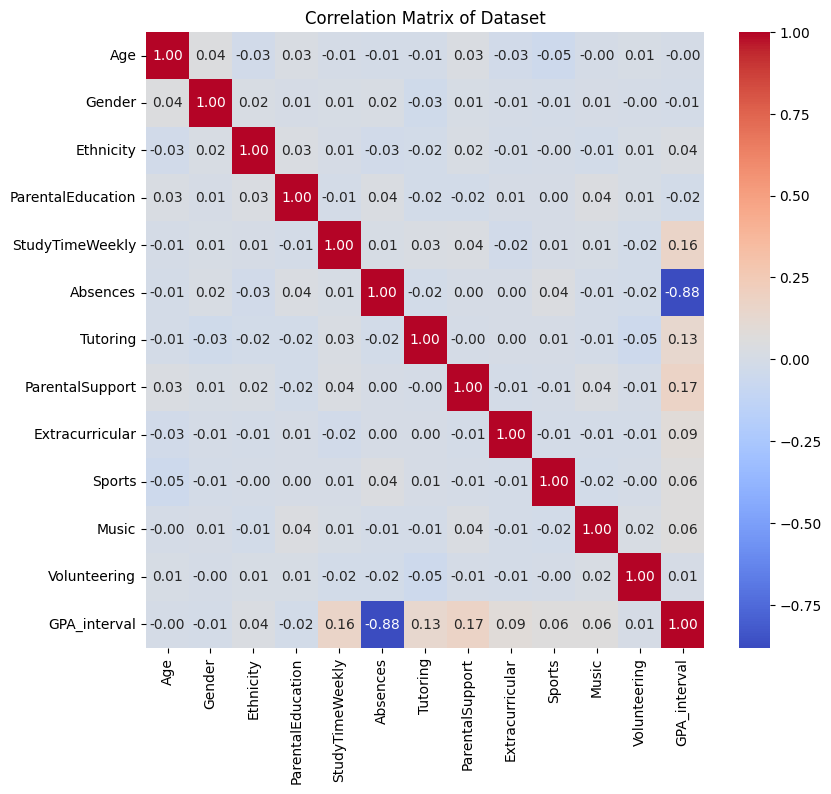

In [10]:
# Stampa la matrice delle correlazioni del dataset

correlation_matrix = dataset.corr()

plt.figure(figsize=(9, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Dataset')
plt.show()


### Outliers
Verifichiamo ora la presenza di outliers nelle features. \
Ci concentriamo sulle features non categoriche, e vediamo che non ci sono outliers.

,StudyTimeWeekly,Absences
count,2392.000,2392.000
mean,0.000,0.000
std,1.000,1.000
min,-1.729,-1.718
25%,-0.837,-0.891
50%,-0.012,0.054
75%,0.820,0.881
max,1.806,1.708


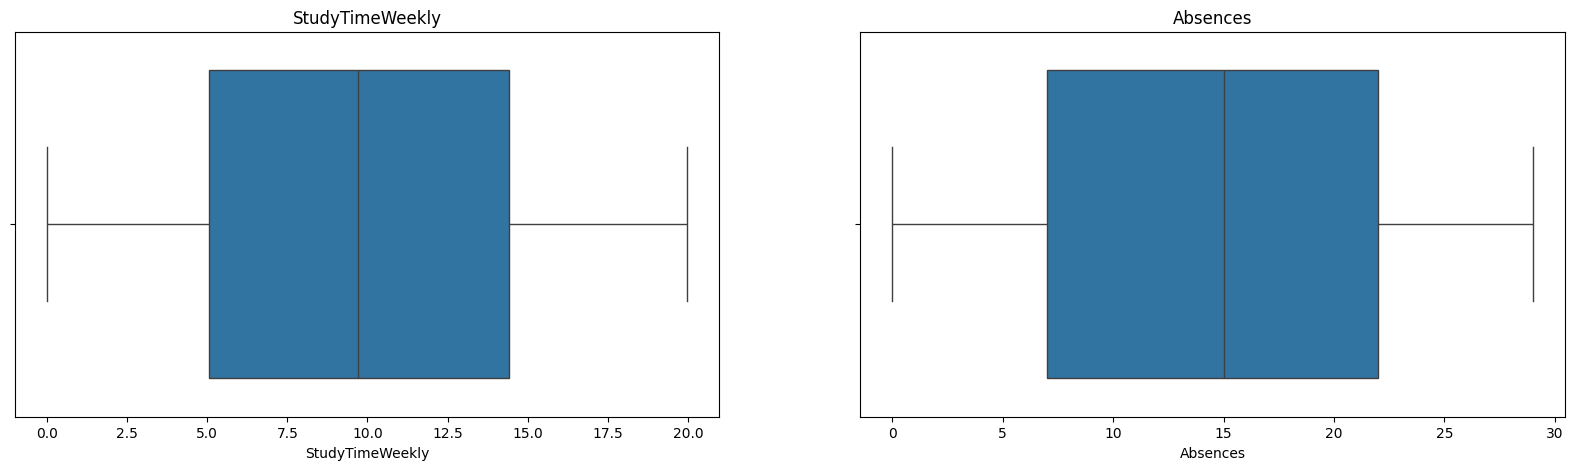

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
idxs = ['StudyTimeWeekly', 'Absences']
for idx in range(2):
    sns.boxplot(ax=ax[idx], x=dataset[idxs[idx]])
    ax[idx].set_title(idxs[idx])

z_scores = stats.zscore(dataset[idxs])
z_scores_df = pd.DataFrame(z_scores, columns=idxs)
z_scores_df.describe().round(3)

## Preparazione dei dati


### Encoding delle variabili categoriche
Effettuiamo l'encoding della variabile `Ethnicity` utilizzando la tecnica dell'encoding one-hot. \
Inoltre droppiamo la categoria `Other` in quanto deducibile dalle altre colonne, e quindi introduce multicollinearità. \
Manteniamo invece la feature `ParentalEducation` come variabile categorica espressa in termini di numeri, in quanto l'ordine crescente dei numeri rispecchia l'ordine dei titoli di studio. \
Lo stesso vale per la feature `ParentalSupport`.
La altre feature binarie sono già numeriche, quindi non necessitano di encoding.

In [12]:
if 'Ethnicity' in featuresDataFrame.columns:
  encoder = OneHotEncoder(sparse_output=False, drop='if_binary', dtype=int)
  encoded_array = encoder.fit_transform(featuresDataFrame[['Ethnicity']])
  df_encoded = pd.DataFrame(encoded_array, columns=['Cau', 'Afr', 'Asi', 'Oth'], dtype=int)
  df_encoded.drop(columns=['Oth'], inplace=True)
  featuresDataFrame = pd.concat([featuresDataFrame, df_encoded], axis=1)
  print(featuresDataFrame[['Ethnicity', 'Cau', 'Afr', 'Asi']].head(10))
  featuresDataFrame.drop(columns=['Ethnicity'], inplace=True)

   Ethnicity  Cau  Afr  Asi
0          0    1    0    0
1          0    1    0    0
2          2    0    0    1
3          0    1    0    0
4          0    1    0    0
5          0    1    0    0
6          1    0    1    0
7          1    0    1    0
8          0    1    0    0
9          0    1    0    0


In [13]:
featuresDataFrame.head(10)

,Age,Gender,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,Cau,Afr,Asi
0,17,1,2,19.833723,7,1,2,0,0,1,0,1,0,0
1,18,0,1,15.408756,0,0,1,0,0,0,0,1,0,0
2,15,0,3,4.210570,26,0,2,0,0,0,0,0,0,1
3,17,1,3,10.028829,14,0,3,1,0,0,0,1,0,0
4,17,1,2,4.672495,17,1,3,0,0,0,0,1,0,0
5,18,0,1,8.191219,0,0,1,1,0,0,0,1,0,0
6,15,0,1,15.601680,10,0,3,0,1,0,0,0,1,0
7,15,1,4,15.424496,22,1,1,1,0,0,0,0,1,0
8,17,0,0,4.562008,1,0,2,0,1,0,1,1,0,0
9,16,1,1,18.444466,0,0,3,1,0,0,0,1,0,0


### Divisione del dataset
Dividiamo il dataset in training set e test set, utilizzando una proporzione di 30% per il training set e 30% per il test set. \
Dividiamo inoltre il training set in training set e validation set, utilizzando una proporzione di 80% per il training set e 20% per il validation set. \

Prepariamo anche i set di target binari per l'addestramento della rete multistrato.



In [14]:
# Suddivisione in istanze di Training, Test e Valutazione
Xtrain, Xtest, Ytrain, Ytest = train_test_split(featuresDataFrame, targetsDataFrame, test_size=0.3, random_state=42)
Xtrain_val, X_val, Ytrain_val, Y_val = train_test_split(Xtrain, Ytrain, test_size=0.2, random_state=42)

# Set di target binarizzati
Ytrain_bin = keras.utils.to_categorical(Ytrain)
Ytest_bin = keras.utils.to_categorical(Ytest)
Ytrain_val_bin = keras.utils.to_categorical(Ytrain_val)
Y_val_bin = keras.utils.to_categorical(Y_val)

# Addestramento dell'albero di decisione

### Ricerca del miglior ccp_alpha
Cerchiamo il miglior ccp_alpha provando tutti i valori restituiti dal metodo `cost_complexity_pruning_path` e scegliendo quello con l'f1-score più alto.

Miglior ccp_alpha trovato: 0.00492, con f1-score: 0.77843


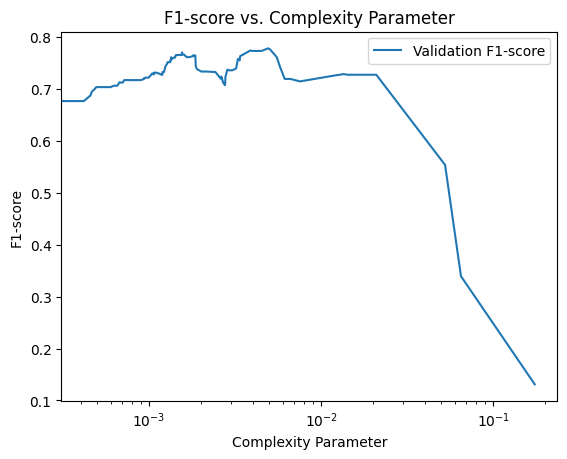

In [15]:
# Crea il modello di decision tree
ccp_tree = DecisionTreeClassifier(random_state=42)
path = ccp_tree.cost_complexity_pruning_path(Xtrain_val, Ytrain_val)

validation_f1 = []
best_alpha = 0
best_f1 = 0

for alpha in path.ccp_alphas:
    ccp_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    ccp_tree.fit(Xtrain_val, Ytrain_val)

    Y_pred_val = ccp_tree.predict(X_val)
    f1 = f1_score(Y_val, Y_pred_val, average='macro')
    validation_f1.append(f1)

    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha

print(f"Miglior ccp_alpha trovato: {best_alpha:.5f}, con f1-score: {best_f1:.5f}")


# Plotta lo score del modello in funzione del parametro di complessità
plt.plot(path.ccp_alphas, validation_f1, label='Validation F1-score')
plt.xlabel('Complexity Parameter')
plt.ylabel('F1-score')
plt.title('F1-score vs. Complexity Parameter')
plt.xscale('log')
plt.legend()
plt.show()

### Tuning degli iperparametri

Individuiamo i migliori iperparametri tramite GridSearch con cross-validation, usando come metrica l'F1-score macroaverage

In [16]:
# Griglia di parametri per il grid search
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'class_weight': ['balanced', None]
}

model = DecisionTreeClassifier(random_state=420, ccp_alpha=best_alpha)

# Crea il grid search con validazione incrociata (5-fold) e fitta il modello
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(Xtrain_val, Ytrain_val)

print(f"Migliori iperparametri: {grid_search.best_params_}")



Migliori iperparametri: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'random'}


## Validazione e test del modello tunato
Eseguiamo le predizioni sul set di validation e di test, confrontiamo i risultati e verifichiamo l'assenza di overfitting.

In [17]:
best_tree = grid_search.best_estimator_
Y_pred_val = best_tree.predict(X_val)

print("Classification Report - Validation Set:")
print(classification_report(Y_val, Y_pred_val, digits=3))

# Valutazione finale sul Test Set
Y_pred_test = best_tree.predict(Xtest)

print("\nClassification Report - Test Set:")
print(classification_report(Ytest, Y_pred_test, digits=3))


Classification Report - Validation Set:
              precision    recall  f1-score   support

           0      0.860     0.683     0.761        63
           1      0.716     0.807     0.759       119
           2      0.718     0.832     0.770       113
           3      0.950     0.475     0.633        40

    accuracy                          0.752       335
   macro avg      0.811     0.699     0.731       335
weighted avg      0.772     0.752     0.748       335


Classification Report - Test Set:
              precision    recall  f1-score   support

           0      0.819     0.693     0.751       137
           1      0.697     0.773     0.733       238
           2      0.724     0.765     0.744       243
           3      0.765     0.620     0.685       100

    accuracy                          0.734       718
   macro avg      0.751     0.713     0.728       718
weighted avg      0.739     0.734     0.734       718



### Modello finale
Ora che abbiamo individuato i migliori iperparametri, addestriamo il modello con l'intero training set e valutiamo le performance sul test set.

Classification Report - Test Set:
              precision    recall  f1-score   support

           0      0.823     0.847     0.835       137
           1      0.757     0.773     0.765       238
           2      0.733     0.770     0.751       243
           3      0.772     0.610     0.682       100

    accuracy                          0.763       718
   macro avg      0.771     0.750     0.758       718
weighted avg      0.764     0.763     0.762       718



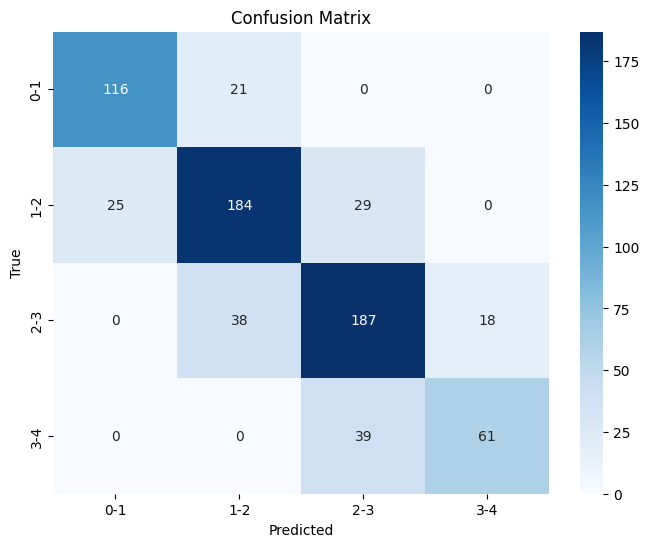

In [18]:
fullyTrainedTree = DecisionTreeClassifier(random_state=42, **grid_search.best_params_)
fullyTrainedTree.fit(Xtrain, Ytrain)

YPredTest = fullyTrainedTree.predict(Xtest)
print("Classification Report - Test Set:")
print(classification_report(Ytest, YPredTest, digits=3))

cm = confusion_matrix(Ytest, YPredTest)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0-1', '1-2', '2-3', '3-4'], yticklabels=['0-1', '1-2', '2-3', '3-4'])
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.show()

In [19]:
# Visualizza l'albero decisionale
fig, ax = plt.subplots(figsize=(150, 100))
plot_tree(best_tree, filled=True, ax=ax)
plt.plot()

[]

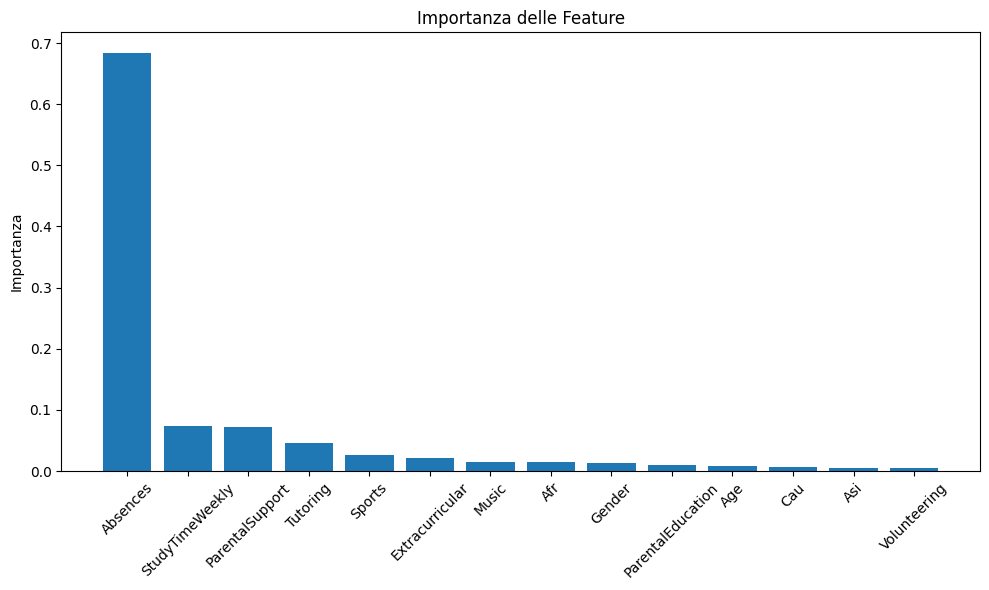

In [20]:
importances = fullyTrainedTree.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = list(featuresDataFrame.columns)

plt.figure(figsize=(10, 6))
plt.title("Importanza delle Feature")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.ylabel("Importanza")
plt.tight_layout()
plt.show()

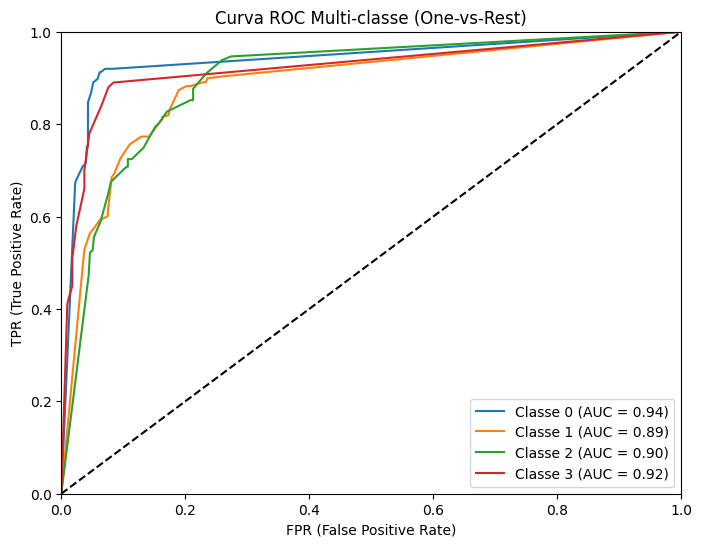

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizza le etichette per calcolare ROC-AUC multiclasse
y_val_bin = label_binarize(Ytest, classes=[0, 1, 2, 3])
y_pred_prob = fullyTrainedTree.predict_proba(Xtest)  # Probabilità di ogni classe

plt.figure(figsize=(8, 6))
for i in range(4):  # Per ogni classe
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Classe {i} (AUC = {roc_auc:.2f})")

plt.margins(0)
plt.plot([0, 1], [0, 1], "k--")  # Linea diagonale
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("Curva ROC Multi-classe (One-vs-Rest)")
plt.legend()
plt.show()


# Addestramento della rete neurale

### Modello
Definizione della classe e della funzione per la creazione del modello.

Early Stopping: Se il modello non migliora per 10 epoche consecutive, l'allenamento viene fermato e il modello viene ripristinato al miglior stato.

Dropout: Con un tasso di 0.2, disattiva casualmente il 20% dei neuroni nei layer densi durante l'allenamento per migliorare la generalizzazione.

Batch Normalization: Applicata ai layer nascosti, normalizza gli input per stabilizzare l'addestramento e accelerare la convergenza

In [22]:
# Funzione per costruire il modello
def create_model(optimizer='adam', hidden_layer_sizes=(50,)):
    model = Sequential()
    model.add(Input(shape=(Xtrain_val.shape[1],)))
    for units in hidden_layer_sizes:
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.2))
    model.add(Dense(4, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['f1_score'])
    return model

class KerasModel(BaseEstimator, ClassifierMixin):
    def __init__(self, optimizer='adam', hidden_layer_sizes=(50,)):
        self.optimizer = optimizer
        self.hidden_layer_sizes = hidden_layer_sizes
        self.model = create_model(optimizer=self.optimizer, hidden_layer_sizes=self.hidden_layer_sizes)

    def fit(self, X, y, epochs=50):
      early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
      self.model.fit(X, y, epochs=epochs, batch_size=64, verbose=0, validation_split=0.1, callbacks=[early_stopping])

    def predict(self, X):
      probs = self.model.predict(X)
      labels = np.argmax(probs, axis=1)  # Trova la classe con la probabilità più alta
      return keras.utils.to_categorical(labels, num_classes=probs.shape[1])  # Converti in one-hot

    def predict_proba(self, X):
        return self.model.predict(X)

### Tuning degli iperparametri

Individuiamo i migliori iperparametri tramite GridSearch con cross-validation, usando come metrica l'F1-score macroaverage

In [23]:
keras_model = KerasModel()

# Definisce la griglia di parametri per il grid search
param_grid = {
    'optimizer': ['adam', 'sgd'],
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (25, 50, 25)],
}

# Esegue il grid search con validazione incrociata (5-fold)
grid_search = GridSearchCV(estimator=keras_model, param_grid=param_grid, cv=5, scoring='f1_macro')
grid_search.fit(Xtrain_val, Ytrain_val_bin)

for f1_macro, params in zip(grid_search.cv_results_["mean_test_score"], grid_search.cv_results_["params"]):
    print(f"F1-macro: {f1_macro:.3f} - Parametri: {params}")

# Stampa i migliori iperparametri
print(f"Migliori iperparametri: {grid_search.best_params_}")


Restoring model weights from the end of the best epoch: 49.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Restoring model weights from the end of the best epoch: 50.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Restoring model weights from the end of the best epoch: 50.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Epoch 50: early stopping
Restoring model weights from the end of the best epoch: 40.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Restoring model weights from the end of the best epoch: 41.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Restoring model weights from the end of the best epoch: 47.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Restoring model weights from the end of the best epoch: 48.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Restoring model weights from the end of the best epoch: 49.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Epoch 50: early stopping
Restoring model weights from the end of the best epoch: 40.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Restoring model weights from the end of the best epoch: 50.
9/9 ━━━━━━━

KeyboardInterrupt: 

In [ ]:
# Usa il modello con i migliori iperparametri per fare predizioni
best_net = grid_search.best_estimator_

# Predizioni sul validation set
Y_pred = best_net.predict(X_val)
print("Classification Report - Validation Set:")
print(classification_report(Y_val_bin, Y_pred, digits=3))

# Valutazione finale sul Test Set
Y_pred_test = best_net.predict(Xtest)
print("\nClassification Report - Test Set:")
print(classification_report(Ytest_bin, Y_pred_test, digits=3))


In [ ]:
keras.utils.plot_model(best_net.model, show_shapes=True)

In [ ]:
best_params_net = best_net.get_params()
fullyTrainedNet = KerasModel(optimizer=best_params_net["optimizer"], hidden_layer_sizes=best_params_net["hidden_layer_sizes"])
fullyTrainedNet.fit(Xtrain, Ytrain_bin, epochs=100)

In [ ]:
YPredNet = fullyTrainedNet.predict(Xtest)
print("Classification Report - Test Set:")
print(classification_report(Ytest_bin, YPredNet, digits=3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0-1', '1-2', '2-3', '3-4'], yticklabels=['0-1', '1-2', '2-3', '3-4'])
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.show()

In [ ]:
# Binarizza le etichette per calcolare ROC-AUC multiclasse
y_test_bin_net = label_binarize(Ytest, classes=[0, 1, 2, 3])
y_pred_prob_net = fullyTrainedNet.predict_proba(Xtest)

plt.figure(figsize=(8, 6))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin_net[:, i], y_pred_prob_net[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Classe {i} (AUC = {roc_auc:.2f})")
# Rimuove il margine dell'origine
plt.margins(x=0, y=0)

plt.plot([0, 1.01], [0, 1.01], "k--")
plt.xlabel("FPR (False Positive Rate)")
plt.ylabel("TPR (True Positive Rate)")
plt.title("Curva ROC Multi-classe (One-vs-Rest)")
plt.legend()
plt.show()